# BTYD from zero to useful: an end-to-end customer value project

BTYD means **Buy Till You Die**.

The name sounds dramatic, but the business question is very practical:

> For customers who can buy whenever they want, who is probably still active, how many purchases should we expect next, and what is that worth?

This notebook is written for a junior analyst, consultant, or product person who has not modeled BTYD before. We will avoid magic. Every idea will be connected to a small business story, visible data, code, and interpretation.

The existing scripts in this folder are the production-style version:

- `01_data_prep.py`: clean transactions and build RFM.
- `02_lifetimes_analysis.py`: fit BG/NBD and Gamma-Gamma with `lifetimes`.
- `03_pymc_analysis.py`: fit Bayesian versions with PyMC-Marketing.
- `04_comparison.py`: compare speed, agreement, ranking, and uncertainty.

Here, we slow down and learn the concepts first.

## 1. When BTYD is the right tool

Use BTYD when all three conditions are true:

| Condition | Meaning | Example |
|---|---|---|
| Customers buy repeatedly | We care about future purchase count, not only one conversion | ecommerce, donations, marketplace orders |
| The relationship is non-contractual | We do not observe a formal cancellation date | a customer simply stops ordering |
| We have transaction history | Purchase dates and amounts are recorded | invoice table, order table, donation table |

BTYD is related to survival analysis, but it is not the same setup.

Survival analysis usually models **time to one event**: churn, death, default, failure.

BTYD models **repeat purchases plus hidden dropout**. A customer may look quiet because they are gone, or because they are alive but not ready to buy today. BTYD tries to separate those two stories.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data, calibration_and_holdout_data
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import spearmanr

# Silence only the noisy-but-harmless categories. RuntimeWarnings stay visible
# on purpose: numerical warnings from the fitters are often the first sign of a
# degenerate fit, and we want to see them.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

## 2. The story: a small online coffee retailer

Imagine a company called **Bean & Byte**. Customers buy coffee beans, filters, mugs, and brewing accessories. There is no cancellation button. If someone stops buying, we only notice silence.

We will generate synthetic transactions so the notebook is self-contained. This simulated world follows the BG/NBD + Gamma-Gamma assumptions **by design**:

- While alive, each customer buys as a Poisson process with a personal purchase rate. Some people are frequent buyers, some are rare buyers.
- After every repeat purchase, the customer flips a personal "dropout coin" and may quietly leave for good. That is the "buy till you die" part.
- Each customer has a personal spend level, and individual order values scatter around it.

Because the data generator matches the model we are about to fit, we can store the hidden truth about each customer (their purchase rate, dropout probability, spend level, and whether they were still alive at the end) and check the fitted model against it later. That is a luxury real data never gives you: real customers never follow the model assumptions this cleanly, which is exactly why the validation sections of this notebook matter.

In real life we do not know those hidden traits. We only see transactions.

In [2]:
RANDOM_SEED = 20260704

# Ground-truth population parameters (stored so the fitted model can be
# validated against the simulated truth later).
R_TRUE, ALPHA_TRUE = 1.3, 45.0   # purchase rate: lambda_i ~ Gamma(r, rate=alpha), purchases/day
A_TRUE, B_TRUE = 1.1, 3.3        # dropout: p_i ~ Beta(a, b), coin flipped after each repeat purchase
P_SHAPE = 6.0                    # order value: z ~ Gamma(p, rate=nu_i), E[z | nu_i] = p / nu_i
Q_TRUE, GAMMA_TRUE = 4.0, 20.0   # spend heterogeneity: nu_i ~ Gamma(q, rate=gamma)


def simulate_transactions(n_customers=1400, seed=RANDOM_SEED):
    """Simulate a coffee retailer that follows the BG/NBD + Gamma-Gamma
    assumptions exactly:

    - while alive, each customer buys as a Poisson process with personal
      rate lambda_i ~ Gamma(r, alpha);
    - after EVERY repeat purchase the customer drops out for good with
      personal probability p_i ~ Beta(a, b) (the "buy till you die" coin);
    - order values are Gamma(p, nu_i), with spend heterogeneity
      nu_i ~ Gamma(q, gamma) across customers (the Gamma-Gamma story).

    Because this simulated world matches the model's assumptions, we can
    validate the fitted model against stored ground truth later. Real data
    never matches this cleanly - which is exactly why the validation
    section matters. The function seeds its own generator, so re-running
    this cell alone reproduces the same data.
    """
    rng = np.random.default_rng(seed)
    obs_start = pd.Timestamp("2024-01-01")
    obs_end = pd.Timestamp("2025-12-31")
    max_signup_offset = 420  # signups spread over the first 14 months

    customer_rows, tx_rows = [], []
    for i in range(n_customers):
        cid = f"BB{i:05d}"
        signup = obs_start + pd.Timedelta(days=int(rng.integers(0, max_signup_offset + 1)))
        lam = rng.gamma(shape=R_TRUE, scale=1.0 / ALPHA_TRUE)
        p_drop = rng.beta(A_TRUE, B_TRUE)
        nu = rng.gamma(shape=Q_TRUE, scale=1.0 / GAMMA_TRUE)

        def order_value():
            return round(max(float(rng.gamma(shape=P_SHAPE, scale=1.0 / nu)), 2.0), 2)

        # First purchase at signup. In BG/NBD the dropout coin is flipped
        # after each REPEAT purchase, not after the very first one.
        tx_rows.append((cid, signup.normalize(), order_value()))
        alive, t = True, signup
        while alive:
            t = t + pd.Timedelta(days=float(rng.exponential(1.0 / lam)))
            if t > obs_end:
                break
            tx_rows.append((cid, t.normalize(), order_value()))
            if rng.random() < p_drop:
                alive = False

        customer_rows.append((cid, signup.normalize(), lam, p_drop, P_SHAPE / nu, alive))

    transactions = (pd.DataFrame(tx_rows, columns=["customer_id", "order_date", "order_value"])
                      .sort_values(["customer_id", "order_date"]).reset_index(drop=True))
    customers = pd.DataFrame(customer_rows, columns=[
        "customer_id", "signup_date", "latent_daily_rate", "latent_dropout_prob",
        "latent_mean_order_value", "alive_at_observation_end_hidden"])
    return transactions, customers, obs_end


transactions, customers, observation_end = simulate_transactions()
print("transactions:", transactions.shape)
print("customers:", customers.shape)
print("observation end:", observation_end.date())
transactions.head()

transactions: (8045, 3)
customers: (1400, 6)
observation end: 2025-12-31


,customer_id,order_date,order_value
0,BB00000,2024-01-01,36.54
1,BB00000,2024-01-08,29.27
2,BB00001,2024-10-16,46.42
3,BB00001,2024-10-18,55.73
4,BB00001,2024-10-25,77.61


In [3]:
summary = transactions.groupby("customer_id").agg(
    first_purchase=("order_date", "min"),
    last_purchase=("order_date", "max"),
    orders=("order_date", "count"),
    total_revenue=("order_value", "sum"),
    avg_order_value=("order_value", "mean"),
).reset_index()
summary["customer_age_days"] = (observation_end - summary["first_purchase"]).dt.days
summary["days_since_last_order"] = (observation_end - summary["last_purchase"]).dt.days

summary.describe().round(2)

,first_purchase,last_purchase,orders,total_revenue,avg_order_value,customer_age_days,days_since_last_order
count,1400,1400,1400.00,1400.00,1400.00,1400.00,1400.00
mean,2024-07-30 15:56:34.285714432,2025-02-11 22:00:41.142856960,5.75,230.15,41.02,518.34,322.08
min,2024-01-01 00:00:00,2024-01-01 00:00:00,1.00,13.00,7.45,310.00,1.00
25%,2024-04-18 12:00:00,2024-09-18 18:00:00,2.00,71.50,23.68,419.00,156.00
50%,2024-07-28 00:00:00,2025-02-01 00:00:00,4.00,134.15,33.26,521.00,333.00
75%,2024-11-07 00:00:00,2025-07-28 00:00:00,7.00,264.46,49.06,621.50,468.25
max,2025-02-24 00:00:00,2025-12-30 00:00:00,65.00,2577.55,496.45,730.00,730.00
std,NaN,NaN,5.91,287.30,32.41,120.46,197.45


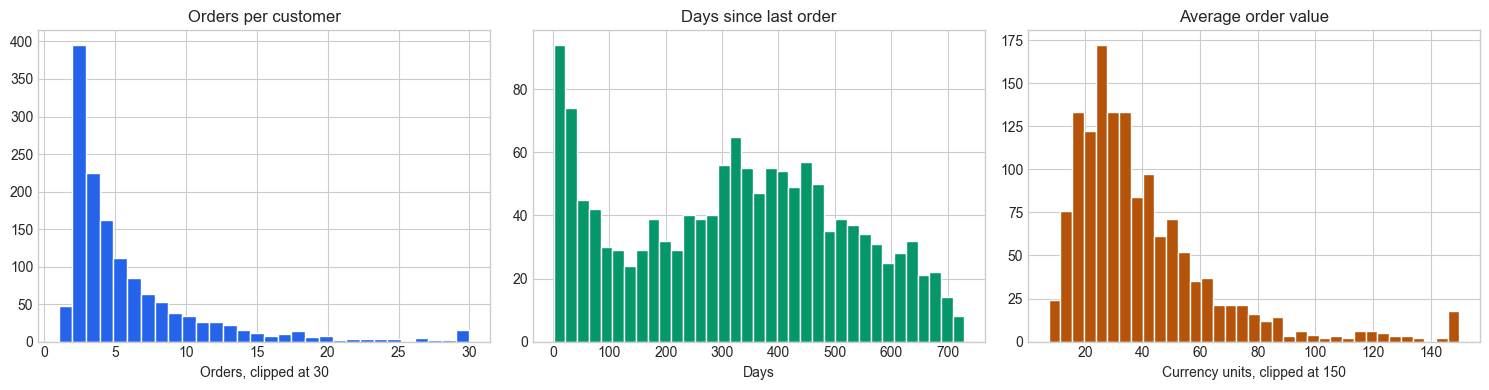

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(summary["orders"].clip(upper=30), bins=30, color="#2563EB", edgecolor="white")
axes[0].set_title("Orders per customer")
axes[0].set_xlabel("Orders, clipped at 30")

axes[1].hist(summary["days_since_last_order"], bins=35, color="#059669", edgecolor="white")
axes[1].set_title("Days since last order")
axes[1].set_xlabel("Days")

axes[2].hist(summary["avg_order_value"].clip(upper=150), bins=35, color="#B45309", edgecolor="white")
axes[2].set_title("Average order value")
axes[2].set_xlabel("Currency units, clipped at 150")

plt.tight_layout()
plt.show()

## 3. The four BTYD columns: frequency, recency, T, monetary value

BTYD does not use a raw transaction table directly. It compresses each customer's history into a small set of sufficient statistics.

| Column | Plain-English meaning | Common beginner mistake |
|---|---|---|
| `frequency` | repeat purchases after the first purchase | thinking it means total purchases |
| `recency` | time between first and most recent purchase | thinking it means days since last purchase |
| `T` | customer age at the end of observation | using a different end date per customer |
| `monetary_value` | average value of repeat purchases | including one-time buyers in Gamma-Gamma |

The names are slightly annoying. Especially `recency`: in lifetimes, high recency means the customer kept buying over a long span. It is not the same as "how recently they bought." We can calculate both, but the model expects the lifetimes definition.

One more subtlety: we build the table with `freq="D"`, so orders placed on the same calendar day merge into one purchase occasion. That means `frequency` can be less than order count minus 1, and `monetary_value` averages day-level spend rather than individual order lines.

In [5]:
rfm = summary_data_from_transaction_data(
    transactions,
    customer_id_col="customer_id",
    datetime_col="order_date",
    monetary_value_col="order_value",
    observation_period_end=observation_end,
    freq="D",  # daily granularity: same-day orders merge into one purchase occasion
)

rfm = rfm.reset_index()
rfm.head(10)

,customer_id,frequency,recency,T,monetary_value
0,BB00000,1.0,7.0,730.0,29.270000
1,BB00001,3.0,117.0,441.0,82.783333
2,BB00002,1.0,94.0,395.0,19.880000
3,BB00003,1.0,62.0,625.0,26.160000
4,BB00004,3.0,307.0,320.0,35.543333
5,BB00005,1.0,22.0,367.0,55.300000
6,BB00006,1.0,90.0,617.0,24.020000
7,BB00007,12.0,294.0,646.0,38.797500
8,BB00008,1.0,21.0,599.0,21.960000
9,BB00009,1.0,11.0,645.0,10.290000


In [6]:
print("Rows:", len(rfm))
print("One-time buyers:", int((rfm["frequency"] == 0).sum()))
print("Repeat buyers:", int((rfm["frequency"] > 0).sum()))
print("Repeat-buyer share:", round((rfm["frequency"] > 0).mean(), 3))
rfm[["frequency", "recency", "T", "monetary_value"]].describe().round(2)

Rows: 1400
One-time buyers: 53
Repeat buyers: 1347
Repeat-buyer share: 0.962


,frequency,recency,T,monetary_value
count,1400.00,1400.00,1400.00,1400.00
mean,4.66,196.25,518.34,39.88
std,5.76,179.11,120.46,34.72
min,0.00,0.00,310.00,0.00
25%,1.00,41.00,419.00,21.91
50%,3.00,143.00,521.00,31.73
75%,6.00,318.00,621.50,48.94
max,60.00,720.00,730.00,483.96


In [7]:
example_customer = rfm.sort_values(["frequency", "T"], ascending=[False, False]).iloc[0]["customer_id"]
example_timeline = transactions[transactions["customer_id"] == example_customer].copy()
example_rfm = rfm[rfm["customer_id"] == example_customer]

print("Example customer:", example_customer)
display(example_rfm)
display(example_timeline.head(12))

Example customer: BB00931


,customer_id,frequency,recency,T,monetary_value
931,BB00931,60.0,417.0,438.0,25.991667


,customer_id,order_date,order_value
5447,BB00931,2024-10-19,62.68
5448,BB00931,2024-11-01,16.94
5449,BB00931,2024-11-23,37.42
5450,BB00931,2024-12-09,26.98
5451,BB00931,2024-12-11,16.91
5452,BB00931,2024-12-11,23.54
5453,BB00931,2024-12-22,40.83
5454,BB00931,2025-01-17,20.88
5455,BB00931,2025-01-20,33.22
5456,BB00931,2025-01-22,40.85


## 4. Fit BG/NBD: buying frequency plus hidden dropout

The BG/NBD model is the workhorse transaction model.

It assumes each customer has:

- A personal purchase rate: some people buy frequently, others rarely.
- A hidden dropout process: after each purchase, the customer may become inactive without telling us.

The model outputs two business-friendly quantities:

- `expected_purchases_180d`: how many purchases we expect in the next 180 days.
- `p_alive`: probability the customer is still active, given their purchase pattern so far.

`p_alive` is not morality, loyalty, or satisfaction. It is a model-based probability that the customer's purchase process has not stopped.

Right after fitting, we print the parameters and sanity-check them. Always do this. A broken fit usually announces itself in the parameters long before it corrupts a downstream table.

In [8]:
# penalizer_coef adds a tiny ridge penalty for numerical stability
# (0.001, consistent with the production scripts in this folder).
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(rfm["frequency"], rfm["recency"], rfm["T"])

print("BG/NBD parameters")
display(bgf.summary.round(4))

# ALWAYS sanity-check fitted parameters before using them.
r, alpha, a, b = (bgf.params_[k] for k in ["r", "alpha", "a", "b"])
print(f"Population purchase rate:  r/alpha = {r / alpha:.4f} purchases per day while alive")
print(f"Dropout coin:              a/(a+b) = {a / (a + b):.3f} mean P(drop out) per repeat purchase")
print(f"a + b = {a + b:.3f}")

# Two failure modes worth catching here, not three sections later:
# 1) In lifetimes, the conditional-expectation formula is numerically fragile
#    when a + b <= 1: it returns NaN for every frequency-0 customer.
# 2) A degenerate a -> 0 means the model thinks nobody ever dies.
assert a + b > 1, "Degenerate BG/NBD fit (a + b <= 1): fix the model before predicting"
print("Sanity check passed: a + b > 1, so conditional expectations are numerically safe")

rfm["expected_purchases_180d"] = bgf.conditional_expected_number_of_purchases_up_to_time(
    180,
    rfm["frequency"],
    rfm["recency"],
    rfm["T"],
)
rfm["p_alive"] = bgf.conditional_probability_alive(
    rfm["frequency"],
    rfm["recency"],
    rfm["T"],
)

rfm[["expected_purchases_180d", "p_alive"]].describe().round(3)

BG/NBD parameters


,coef,se(coef),lower 95% bound,upper 95% bound
r,1.4083,0.0713,1.2685,1.5480
alpha,51.3783,3.2962,44.9178,57.8387
a,0.9339,0.0707,0.7953,1.0725
b,2.5047,0.2515,2.0117,2.9977


Population purchase rate:  r/alpha = 0.0274 purchases per day while alive
Dropout coin:              a/(a+b) = 0.272 mean P(drop out) per repeat purchase
a + b = 3.439
Sanity check passed: a + b > 1, so conditional expectations are numerically safe


,expected_purchases_180d,p_alive
count,1400.000,1400.000
mean,0.650,0.276
std,1.391,0.344
min,0.000,0.000
25%,0.010,0.010
50%,0.070,0.063
75%,0.570,0.572
max,15.906,1.000


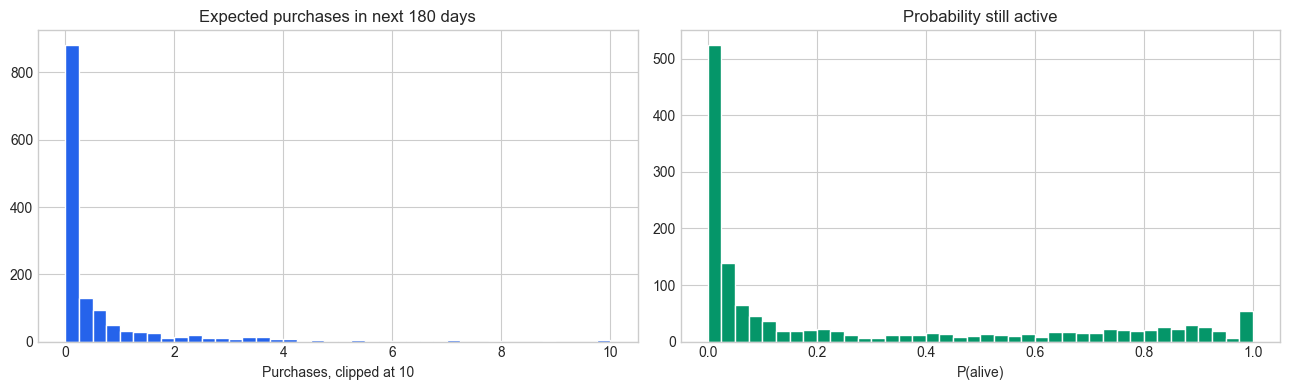

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(rfm["expected_purchases_180d"].clip(upper=10), bins=40, color="#2563EB", edgecolor="white")
axes[0].set_title("Expected purchases in next 180 days")
axes[0].set_xlabel("Purchases, clipped at 10")

axes[1].hist(rfm["p_alive"], bins=40, color="#059669", edgecolor="white")
axes[1].set_title("Probability still active")
axes[1].set_xlabel("P(alive)")

plt.tight_layout()
plt.show()

Notice the spike at exactly 1.0 in the P(alive) histogram. Those are the 53 one-time buyers: in BG/NBD the dropout coin is only flipped after a **repeat** purchase, so a customer who never made one has had no opportunity to die, and their `p_alive` is exactly 1.0 by construction. It is an artifact of the model's structure, not an estimate of engagement.

In [10]:
inspect_cols = ["customer_id", "frequency", "recency", "T", "monetary_value", "expected_purchases_180d", "p_alive"]
rfm.sort_values("expected_purchases_180d", ascending=False)[inspect_cols].head(10).round(3)

,customer_id,frequency,recency,T,monetary_value,expected_purchases_180d,p_alive
931,BB00931,60.0,417.0,438.0,25.992,15.906,0.817
720,BB00720,43.0,531.0,537.0,25.536,11.605,0.968
133,BB00133,40.0,478.0,490.0,35.454,11.386,0.946
410,BB00410,45.0,595.0,596.0,55.803,11.261,0.979
904,BB00904,48.0,628.0,642.0,24.948,10.948,0.951
409,BB00409,32.0,443.0,467.0,28.325,8.887,0.880
426,BB00426,31.0,520.0,544.0,33.391,7.814,0.902
1335,BB01335,27.0,555.0,556.0,68.139,7.218,0.967
527,BB00527,18.0,336.0,340.0,22.623,7.080,0.945
801,BB00801,26.0,541.0,544.0,24.200,7.058,0.962


### Future `P(alive)` curve: what if no new purchase arrives?

`p_alive` can be read like a non-contractual cousin of a survival curve, but with one important difference: it is not calendar survival from a known churn date. It is the model's belief that the customer's buying process is still alive, given the purchase pattern observed so far.

The curve below uses a single illustrative customer:

- first purchase: `2024-01-01`
- last observed purchase / scoring date: `2026-07-06`
- future horizon: 12 months after the scoring date

Before `2026-07-06`, the curve updates whenever a purchase happens. After the vertical divider, we simulate **no new purchases**. Frequency and recency stay frozen, `T` keeps growing, and `p_alive` decays. That decay is the practical win-back signal: if a customer crosses your action threshold with no new purchase, engage before the probability collapses.

If a new purchase happens after the divider, this exact curve is no longer the forecast: you recompute RFM on the new date and the curve updates again.


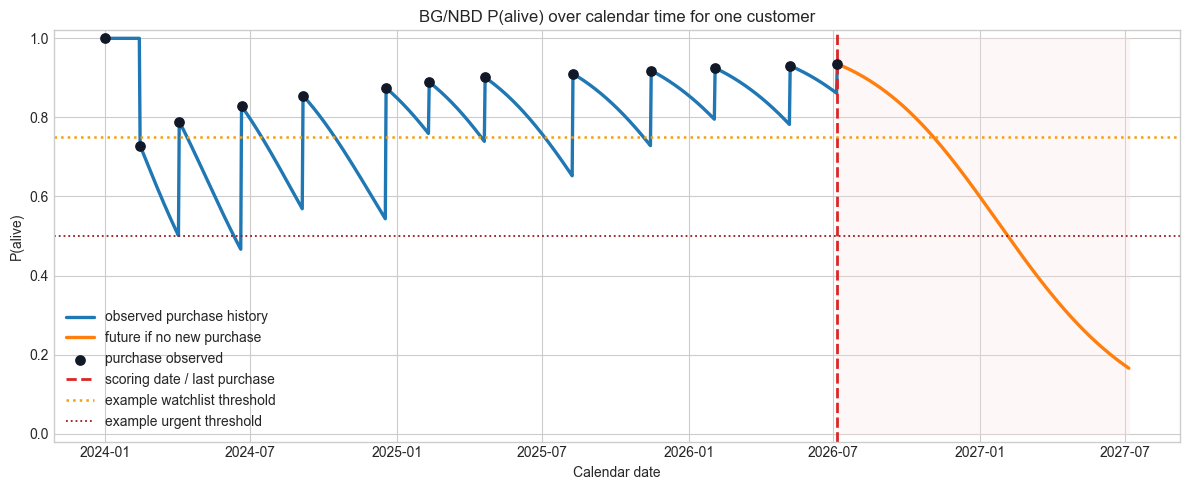

Customer X purchase dates:
2024-01-01, 2024-02-14, 2024-04-03, 2024-06-20, 2024-09-05, 2024-12-18, 2025-02-10, 2025-04-21, 2025-08-09, 2025-11-15, 2026-02-03, 2026-05-08, 2026-07-06

P(alive) checkpoints if no new purchase arrives after 2026-07-06:


,date,p_alive_if_no_new_purchase
0,2026-07-06,0.935
1,2026-10-06,0.811
2,2027-01-06,0.584
3,2027-07-06,0.166


Action-threshold crossing dates:


,threshold,first_crossing_date_if_no_new_purchase
0,0.75,2026-11-04
1,0.50,2027-02-05


In [11]:
demo_purchase_dates = pd.to_datetime([
    '2024-01-01', '2024-02-14', '2024-04-03', '2024-06-20',
    '2024-09-05', '2024-12-18', '2025-02-10', '2025-04-21',
    '2025-08-09', '2025-11-15', '2026-02-03', '2026-05-08', '2026-07-06',
])
first_purchase = demo_purchase_dates.min()
last_observed_purchase = pd.Timestamp('2026-07-06')
future_end = last_observed_purchase + pd.DateOffset(months=12)

timeline = pd.date_range(first_purchase, future_end, freq='D')
curve_rows = []
for as_of_date in timeline:
    observed_dates = demo_purchase_dates[demo_purchase_dates <= as_of_date]
    last_seen = observed_dates.max()
    frequency = float(len(observed_dates) - 1)
    recency = float((last_seen - first_purchase).days) if frequency > 0 else 0.0
    T = float((as_of_date - first_purchase).days)
    p_alive_today = float(np.asarray(bgf.conditional_probability_alive(frequency, recency, T)).ravel()[0])
    curve_rows.append({
        'as_of_date': as_of_date,
        'frequency': frequency,
        'recency': recency,
        'T': T,
        'p_alive': p_alive_today,
        'period': 'observed purchase history' if as_of_date <= last_observed_purchase else 'future if no new purchase',
    })

p_alive_curve = pd.DataFrame(curve_rows)
thresholds = [0.75, 0.50]

fig, ax = plt.subplots(figsize=(12, 5))
for period, grp in p_alive_curve.groupby('period', sort=False):
    ax.plot(grp['as_of_date'], grp['p_alive'], linewidth=2.4, label=period)

purchase_points = p_alive_curve[p_alive_curve['as_of_date'].isin(demo_purchase_dates)]
ax.scatter(purchase_points['as_of_date'], purchase_points['p_alive'], s=45, color='#111827', zorder=3, label='purchase observed')
ax.axvline(last_observed_purchase, color='#DC2626', linestyle='--', linewidth=2, label='scoring date / last purchase')
ax.axhline(0.75, color='#F59E0B', linestyle=':', linewidth=1.8, label='example watchlist threshold')
ax.axhline(0.50, color='#991B1B', linestyle=':', linewidth=1.3, label='example urgent threshold')
ax.fill_between(
    p_alive_curve.loc[p_alive_curve['as_of_date'] >= last_observed_purchase, 'as_of_date'],
    0,
    1,
    color='#FEE2E2',
    alpha=0.25,
)
ax.set_title('BG/NBD P(alive) over calendar time for one customer')
ax.set_xlabel('Calendar date')
ax.set_ylabel('P(alive)')
ax.set_ylim(-0.02, 1.02)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

asof_summary_dates = [
    last_observed_purchase,
    last_observed_purchase + pd.DateOffset(months=3),
    last_observed_purchase + pd.DateOffset(months=6),
    last_observed_purchase + pd.DateOffset(months=12),
]
summary_rows = []
for d in asof_summary_dates:
    nearest = p_alive_curve.iloc[(p_alive_curve['as_of_date'] - d).abs().argsort()[:1]].iloc[0]
    summary_rows.append({'date': nearest['as_of_date'].date(), 'p_alive_if_no_new_purchase': nearest['p_alive']})

crossing_rows = []
future_curve = p_alive_curve[p_alive_curve['as_of_date'] >= last_observed_purchase]
for threshold in thresholds:
    crossed = future_curve[future_curve['p_alive'] <= threshold]
    crossing_rows.append({
        'threshold': threshold,
        'first_crossing_date_if_no_new_purchase': crossed['as_of_date'].iloc[0].date() if len(crossed) else 'not within 12 months',
    })

print('Customer X purchase dates:')
print(', '.join(d.strftime('%Y-%m-%d') for d in demo_purchase_dates))
print()
print('P(alive) checkpoints if no new purchase arrives after 2026-07-06:')
display(pd.DataFrame(summary_rows).round(3))
print('Action-threshold crossing dates:')
display(pd.DataFrame(crossing_rows))


## 5. Validate with a calibration and holdout split

A professional BTYD workflow should ask:

> If we train on the earlier part of history, can we predict purchases in the later part?

This is not perfect validation, but it is much better than fitting once and admiring the output.

In [12]:
calibration_end = observation_end - pd.Timedelta(days=180)

cal_holdout = calibration_and_holdout_data(
    transactions,
    customer_id_col="customer_id",
    datetime_col="order_date",
    calibration_period_end=calibration_end,
    observation_period_end=observation_end,
    freq="D",
)

bgf_cal = BetaGeoFitter(penalizer_coef=0.001)
bgf_cal.fit(cal_holdout["frequency_cal"], cal_holdout["recency_cal"], cal_holdout["T_cal"])

holdout_days = (observation_end - calibration_end).days
cal_holdout["predicted_holdout_purchases"] = bgf_cal.conditional_expected_number_of_purchases_up_to_time(
    holdout_days,
    cal_holdout["frequency_cal"],
    cal_holdout["recency_cal"],
    cal_holdout["T_cal"],
)

# Predictions must exist for EVERY customer. If this assert fires, the fit is
# in the degenerate a + b <= 1 regime and the model (not the data) needs
# fixing. Quietly dropping NaN rows here would bias every metric below.
assert cal_holdout["predicted_holdout_purchases"].notna().all(), (
    "NaN predictions found: check the calibration fit (a + b <= 1?)"
)

eval_df = cal_holdout.copy()
actual = eval_df["frequency_holdout"]
pred = eval_df["predicted_holdout_purchases"]
mae = mean_absolute_error(actual, pred)
rmse = mean_squared_error(actual, pred) ** 0.5
rank_corr = spearmanr(actual, pred).statistic
total_pred, total_actual = pred.sum(), actual.sum()

print(f"Holdout window: {holdout_days} days")
print(f"Evaluated customers: {len(eval_df):,} of {len(cal_holdout):,}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Spearman rank correlation: {rank_corr:.3f}")
print(f"Aggregate bias: predicted {total_pred:,.0f} vs actual {total_actual:,.0f} "
      f"holdout purchases ({(total_pred / total_actual - 1) * 100:+.1f}%)")
eval_df[["frequency_cal", "recency_cal", "T_cal", "frequency_holdout", "predicted_holdout_purchases"]].head()

Holdout window: 180 days
Evaluated customers: 1,400 of 1,400
MAE: 0.827
RMSE: 1.558
Spearman rank correlation: 0.588
Aggregate bias: predicted 1,388 vs actual 1,235 holdout purchases (+12.4%)


,frequency_cal,recency_cal,T_cal,frequency_holdout,predicted_holdout_purchases
customer_id,,,,,
BB00000,1.0,7.0,550.0,0.0,0.006367
BB00001,3.0,117.0,261.0,0.0,0.529699
BB00002,1.0,94.0,215.0,0.0,0.517905
BB00003,1.0,62.0,445.0,0.0,0.055463
BB00004,1.0,38.0,140.0,2.0,0.531270


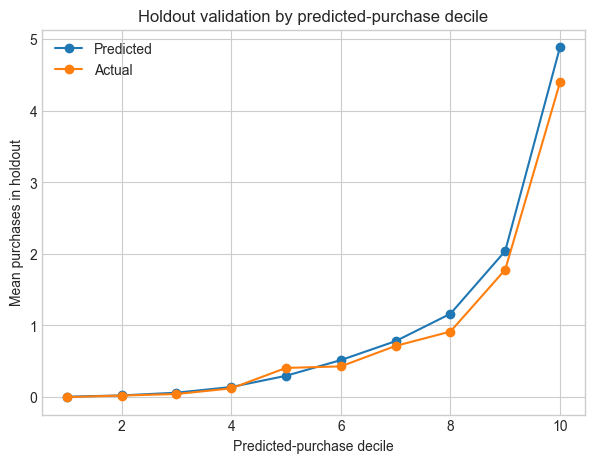

,customers,predicted_purchases,actual_purchases
0,140,0.005,0.000
1,140,0.023,0.021
2,140,0.061,0.043
3,140,0.140,0.121
4,140,0.297,0.407
5,140,0.516,0.429
6,140,0.781,0.714
7,140,1.163,0.914
8,140,2.039,1.779
9,140,4.886,4.393


In [13]:
plot_df = eval_df.copy()
plot_df["pred_bin"] = pd.qcut(plot_df["predicted_holdout_purchases"], q=10, duplicates="drop")
calibration_table = plot_df.groupby("pred_bin", observed=True).agg(
    customers=("frequency_holdout", "size"),
    predicted_purchases=("predicted_holdout_purchases", "mean"),
    actual_purchases=("frequency_holdout", "mean"),
).reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(calibration_table.index + 1, calibration_table["predicted_purchases"], marker="o", label="Predicted")
ax.plot(calibration_table.index + 1, calibration_table["actual_purchases"], marker="o", label="Actual")
ax.set_title("Holdout validation by predicted-purchase decile")
ax.set_xlabel("Predicted-purchase decile")
ax.set_ylabel("Mean purchases in holdout")
ax.legend()
plt.show()

calibration_table[["customers", "predicted_purchases", "actual_purchases"]].round(3)

## 6. Fit Gamma-Gamma: expected money per purchase

BG/NBD predicts **how many** purchases. Gamma-Gamma predicts **how much money per purchase**.

Gamma-Gamma uses only customers with repeat purchases, because one-time buyers have no repeat-purchase monetary average.

Important assumption:

> Purchase frequency and average order value should not be strongly correlated.

If the correlation is high, the model is forcing apart two behaviors that are actually linked. That does not automatically kill the project, but it should make you cautious.

In [14]:
repeat_customers = rfm[(rfm["frequency"] > 0) & (rfm["monetary_value"] > 0)].copy()
pearson_corr = repeat_customers[["frequency", "monetary_value"]].corr().iloc[0, 1]
spearman_corr = spearmanr(repeat_customers["frequency"], repeat_customers["monetary_value"]).statistic
print(f"Correlation between frequency and monetary_value: Pearson {pearson_corr:.3f}, Spearman {spearman_corr:.3f}")

ggf = GammaGammaFitter(penalizer_coef=0.001)  # same tiny ridge penalty for stability
ggf.fit(repeat_customers["frequency"], repeat_customers["monetary_value"])

display(ggf.summary.round(4))

# ALWAYS sanity-check here too. Gamma-Gamma shrinks each customer's raw
# average toward a population mean spend of p*v/(q-1), which only exists when
# q > 1. If q <= 1 the implied mean is undefined and the "shrinkage" pushes
# predictions AWAY from the data instead of toward a population mean.
p_gg, q_gg, v_gg = (ggf.params_[k] for k in ["p", "q", "v"])
assert q_gg > 1, "Degenerate Gamma-Gamma fit (q <= 1): implied population mean spend is undefined"
print(f"Sanity check passed: q = {q_gg:.3f} > 1")
print(f"Implied population mean order value: p*v/(q-1) = {p_gg * v_gg / (q_gg - 1):.2f}")
print(f"Observed mean repeat-purchase value: {repeat_customers['monetary_value'].mean():.2f}")

repeat_customers["expected_avg_order_value"] = ggf.conditional_expected_average_profit(
    repeat_customers["frequency"],
    repeat_customers["monetary_value"],
)
repeat_customers[["monetary_value", "expected_avg_order_value"]].describe().round(2)

Correlation between frequency and monetary_value: Pearson -0.024, Spearman 0.056


,coef,se(coef),lower 95% bound,upper 95% bound
p,8.6532,0.3396,7.9876,9.3187
q,2.5095,0.0940,2.3253,2.6938
v,8.1963,0.3535,7.5035,8.8891


Sanity check passed: q = 2.510 > 1
Implied population mean order value: p*v/(q-1) = 46.98
Observed mean repeat-purchase value: 41.44


,monetary_value,expected_avg_order_value
count,1347.00,1347.00
mean,41.44,41.85
std,34.47,31.51
min,4.66,7.60
25%,23.23,25.01
50%,32.89,34.02
75%,49.68,49.55
max,483.96,465.69


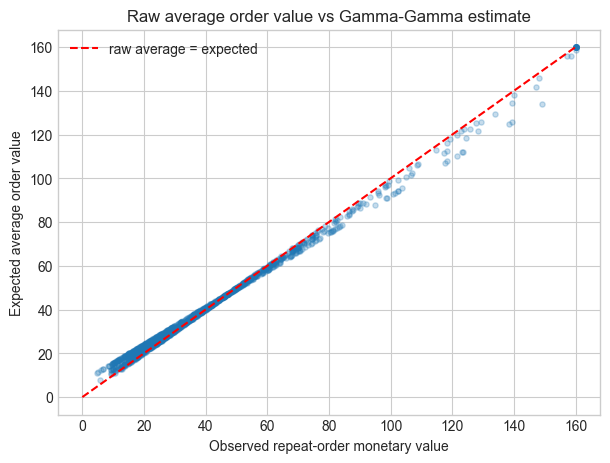

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    repeat_customers["monetary_value"].clip(upper=160),
    repeat_customers["expected_avg_order_value"].clip(upper=160),
    alpha=0.25,
    s=14,
)
ax.plot([0, 160], [0, 160], color="red", linestyle="--", label="raw average = expected")
ax.set_title("Raw average order value vs Gamma-Gamma estimate")
ax.set_xlabel("Observed repeat-order monetary value")
ax.set_ylabel("Expected average order value")
ax.legend()
plt.show()

## 7. Validate against the simulated truth

Because we built this world ourselves, we can do something impossible with real data: open the box and compare the model's beliefs to the hidden truth stored in the `customers` table.

Three checks:

1. **Population level.** Does the average `p_alive` match the true share of customers still alive at the end of the observation window?
2. **Ranking.** If we sort customers by `p_alive`, do the truly-alive ones rise to the top? (ROC-AUC against the hidden alive flag.)
3. **Spend.** Does the Gamma-Gamma estimate of each repeat customer's average order value track their true latent spend level?

In [16]:
truth_check = rfm.merge(
    customers[["customer_id", "alive_at_observation_end_hidden"]],
    on="customer_id",
)

mean_p_alive = truth_check["p_alive"].mean()
true_alive_share = truth_check["alive_at_observation_end_hidden"].mean()
print(f"Mean p_alive across customers:      {mean_p_alive:.3f}")
print(f"True share still alive at obs end:  {true_alive_share:.3f}")

alive_auc = roc_auc_score(truth_check["alive_at_observation_end_hidden"], truth_check["p_alive"])
print(f"ROC-AUC of p_alive vs hidden alive flag: {alive_auc:.3f}")

spend_check = repeat_customers.merge(
    customers[["customer_id", "latent_mean_order_value"]],
    on="customer_id",
)
spend_corr = np.corrcoef(spend_check["expected_avg_order_value"], spend_check["latent_mean_order_value"])[0, 1]
print(f"Correlation of Gamma-Gamma estimate vs latent mean order value (repeat customers): {spend_corr:.3f}")

Mean p_alive across customers:      0.276
True share still alive at obs end:  0.262
ROC-AUC of p_alive vs hidden alive flag: 0.941
Correlation of Gamma-Gamma estimate vs latent mean order value (repeat customers): 0.890


These numbers are good: mean `p_alive` (0.276) lands within about a point and a half of the true alive share (0.262), the ranking AUC is about 0.94, and the spend estimates correlate at about 0.89 with the latent truth.

Be honest about why. **The world here IS the model.** We simulated customers who follow the BG/NBD dropout story exactly, so the model recovers the truth almost by definition. If the true dropout story were different - say customers die in calendar time regardless of whether they purchase, which is the Pareto/NBD world - `p_alive` would be systematically overconfident for quiet customers, and no amount of refitting BG/NBD would repair that. On real data you never get to open the box. Validate against a holdout window, as in section 5, and never assume the model's story is the true one.

## 8. Estimate customer lifetime value

A simple BTYD CLV idea is:

> expected future purchases x expected value per purchase, adjusted for discounting

The `lifetimes` implementation handles the math for us. We will estimate 6-month CLV using:

- BG/NBD for future purchase count.
- Gamma-Gamma for value per purchase.
- A small monthly discount rate.

This is expected value, not guaranteed revenue.

In [17]:
repeat_customers["clv_6m"] = ggf.customer_lifetime_value(
    transaction_prediction_model=bgf,
    frequency=repeat_customers["frequency"],
    recency=repeat_customers["recency"],
    T=repeat_customers["T"],
    monetary_value=repeat_customers["monetary_value"],
    time=6,
    freq="D",
    discount_rate=0.01,
)

repeat_customers["expected_purchases_180d"] = rfm.set_index("customer_id").loc[
    repeat_customers["customer_id"], "expected_purchases_180d"
].values
repeat_customers["p_alive"] = rfm.set_index("customer_id").loc[
    repeat_customers["customer_id"], "p_alive"
].values

repeat_customers[["expected_purchases_180d", "expected_avg_order_value", "p_alive", "clv_6m"]].describe().round(2)

,expected_purchases_180d,expected_avg_order_value,p_alive,clv_6m
count,1347.00,1347.00,1347.00,1347.00
mean,0.66,41.85,0.25,26.18
std,1.42,31.51,0.32,65.30
min,0.00,7.60,0.00,0.00
25%,0.01,25.01,0.01,0.31
50%,0.06,34.02,0.05,2.02
75%,0.59,49.55,0.48,19.43
max,15.91,465.69,0.98,910.20


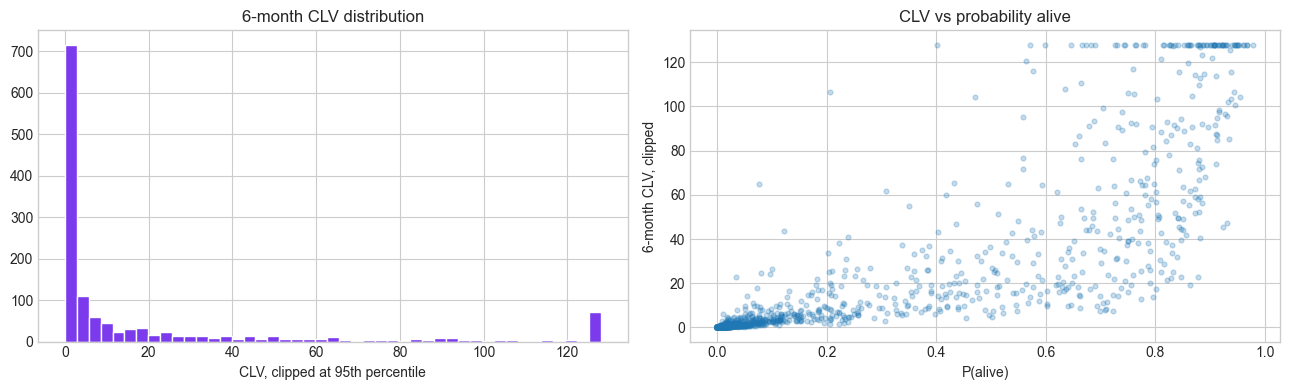

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(repeat_customers["clv_6m"].clip(upper=repeat_customers["clv_6m"].quantile(0.95)), bins=45, color="#7C3AED", edgecolor="white")
axes[0].set_title("6-month CLV distribution")
axes[0].set_xlabel("CLV, clipped at 95th percentile")

axes[1].scatter(repeat_customers["p_alive"], repeat_customers["clv_6m"].clip(upper=repeat_customers["clv_6m"].quantile(0.95)), alpha=0.25, s=12)
axes[1].set_title("CLV vs probability alive")
axes[1].set_xlabel("P(alive)")
axes[1].set_ylabel("6-month CLV, clipped")

plt.tight_layout()
plt.show()

In [19]:
repeat_customers.sort_values("clv_6m", ascending=False)[
    ["customer_id", "frequency", "recency", "T", "monetary_value", "expected_purchases_180d", "p_alive", "expected_avg_order_value", "clv_6m"]
].head(12).round(2)

,customer_id,frequency,recency,T,monetary_value,expected_purchases_180d,p_alive,expected_avg_order_value,clv_6m
335,BB00335,11.0,307.0,317.0,207.86,4.58,0.90,205.35,910.20
410,BB00410,45.0,595.0,596.0,55.80,11.26,0.98,55.77,607.28
297,BB00297,22.0,384.0,426.0,99.34,5.67,0.74,98.92,542.26
1300,BB01300,25.0,439.0,465.0,76.59,7.04,0.88,76.38,520.26
395,BB00395,13.0,598.0,605.0,157.29,3.30,0.93,155.83,496.58
1335,BB01335,27.0,555.0,556.0,68.14,7.22,0.97,68.00,474.63
831,BB00831,31.0,539.0,578.0,64.52,6.71,0.81,64.42,418.22
931,BB00931,60.0,417.0,438.0,25.99,15.91,0.82,26.05,400.83
953,BB00953,9.0,358.0,363.0,119.29,3.50,0.91,117.92,398.79
380,BB00380,8.0,277.0,324.0,148.17,2.82,0.74,146.01,397.79


### Leakage-free 180-day CLTV backtest: `lifetimes` vs feature-engineered ML

The earlier holdout check evaluated **purchase counts**. CLTV is harder: it combines whether the customer buys, how often they buy, and how much they spend.

We now run a proper backtest:

1. Pick a calibration date 180 days before the observation end.
2. Build all features from transactions **on or before** that date.
3. Define the target as actual revenue in the next 180 days.
4. Split customers before fitting anything.
5. Fit `lifetimes` only on the training customers' calibration RFM.
6. Fit a simple random-forest regressor on leakage-free RFM/T and last-window features.
7. Report both models once on held-out customers.

We evaluate only customers with at least one repeat purchase before the calibration date, because Gamma-Gamma needs a repeat-purchase monetary average. One-time buyers should be handled by a separate new/unproven policy, not silently forced through a model that cannot honestly score them.

One important nuance: the ML regressor learns from train customers' future 180-day revenue and is evaluated on disjoint test customers. That is leakage-free for a customer-level benchmark, but a production ML system should be trained on older completed windows and tested on later windows. The synthetic data here are stationary, so this simpler customer split is enough to teach the model-family comparison without introducing calendar drift.


Calibration end: 2025-07-04
Holdout window: 180 days
Eligible repeat customers: 1,308 of 1,400
Train/test customers: 850 458
Train/test holdout-purchase rate: 0.265 0.264


,model,MAE,RMSE,Spearman,aggregate_bias_pct,predicted_total,actual_total
0,Lifetimes BG/NBD + Gamma-Gamma,38.08,91.88,0.592,1.9,18889.0,18537.0
1,RandomForest on leakage-free RFMT features,39.91,92.18,0.557,-9.8,16724.0,18537.0
2,Last-180d revenue run-rate baseline,61.92,147.29,0.537,91.7,35537.0,18537.0


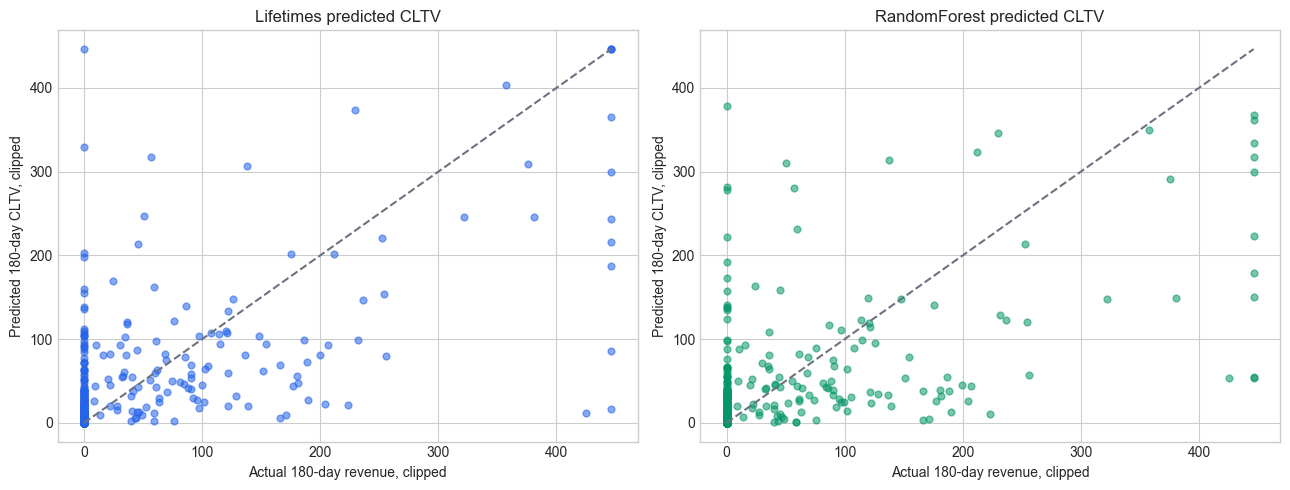

Leakage audit:
- Customer split happens before either model is fit.
- Lifetimes population parameters are fit on train customers only.
- ML features use transactions dated on or before the calibration end only.
- Actual holdout revenue is used as the ML target for train customers and for final test reporting only.


In [20]:
def build_cltv_backtest_frame(transactions, calibration_end, observation_end):
    tx = transactions.copy()
    tx['order_date'] = pd.to_datetime(tx['order_date'])
    cal_tx = tx[tx['order_date'] <= calibration_end].copy()
    holdout_tx = tx[(tx['order_date'] > calibration_end) & (tx['order_date'] <= observation_end)].copy()

    cal_rfm = summary_data_from_transaction_data(
        cal_tx,
        customer_id_col='customer_id',
        datetime_col='order_date',
        monetary_value_col='order_value',
        observation_period_end=calibration_end,
        freq='D',
    ).reset_index()

    daily = cal_tx.groupby(['customer_id', 'order_date'], as_index=False)['order_value'].sum()
    overall = daily.groupby('customer_id').agg(
        first_purchase=('order_date', 'min'),
        last_purchase=('order_date', 'max'),
        purchase_days_cal=('order_date', 'count'),
        total_sales_cal=('order_value', 'sum'),
        avg_day_value_cal=('order_value', 'mean'),
    ).reset_index()
    overall['days_since_last_purchase_cal'] = (calibration_end - overall['last_purchase']).dt.days

    def window_features(days):
        start = calibration_end - pd.Timedelta(days=days)
        win = daily[daily['order_date'] > start]
        out = win.groupby('customer_id').agg(
            **{
                f'purchase_days_last_{days}d': ('order_date', 'count'),
                f'sales_last_{days}d': ('order_value', 'sum'),
                f'avg_day_value_last_{days}d': ('order_value', 'mean'),
            }
        ).reset_index()
        return out

    frame = cal_rfm.merge(overall, on='customer_id', how='left')
    for days in [90, 180]:
        frame = frame.merge(window_features(days), on='customer_id', how='left')

    actual_revenue = holdout_tx.groupby('customer_id')['order_value'].sum().rename('actual_revenue_180d')
    frame = frame.merge(actual_revenue, on='customer_id', how='left')
    frame['actual_revenue_180d'] = frame['actual_revenue_180d'].fillna(0.0)

    fill_cols = [c for c in frame.columns if c.startswith(('purchase_days_last_', 'sales_last_', 'avg_day_value_last_'))]
    frame[fill_cols] = frame[fill_cols].fillna(0.0)
    frame['has_holdout_purchase'] = (frame['actual_revenue_180d'] > 0).astype(int)
    return frame

cltv_frame = build_cltv_backtest_frame(transactions, calibration_end, observation_end)
cltv_eligible = cltv_frame[(cltv_frame['frequency'] > 0) & (cltv_frame['monetary_value'] > 0)].copy()

train_ids, test_ids = train_test_split(
    cltv_eligible['customer_id'],
    test_size=0.35,
    random_state=RANDOM_SEED,
    stratify=cltv_eligible['has_holdout_purchase'],
)
train_cltv = cltv_eligible[cltv_eligible['customer_id'].isin(train_ids)].copy()
test_cltv = cltv_eligible[cltv_eligible['customer_id'].isin(test_ids)].copy()

print(f'Calibration end: {calibration_end.date()}')
print(f'Holdout window: {(observation_end - calibration_end).days} days')
print(f'Eligible repeat customers: {len(cltv_eligible):,} of {len(cltv_frame):,}')
print('Train/test customers:', len(train_cltv), len(test_cltv))
print('Train/test holdout-purchase rate:', round(train_cltv['has_holdout_purchase'].mean(), 3), round(test_cltv['has_holdout_purchase'].mean(), 3))

# Fit lifetimes on TRAIN calibration history only, then score held-out customers.
bgf_ltv = BetaGeoFitter(penalizer_coef=0.001)
bgf_ltv.fit(train_cltv['frequency'], train_cltv['recency'], train_cltv['T'])
r_ltv, alpha_ltv, a_ltv, b_ltv = (bgf_ltv.params_[k] for k in ['r', 'alpha', 'a', 'b'])
assert a_ltv + b_ltv > 1, 'Degenerate BG/NBD calibration fit: a + b <= 1'

ggf_ltv = GammaGammaFitter(penalizer_coef=0.001)
ggf_ltv.fit(train_cltv['frequency'], train_cltv['monetary_value'])
p_ltv, q_ltv, v_ltv = (ggf_ltv.params_[k] for k in ['p', 'q', 'v'])
assert q_ltv > 1, 'Degenerate Gamma-Gamma calibration fit: q <= 1'

test_cltv['lifetimes_clv_180d'] = ggf_ltv.customer_lifetime_value(
    transaction_prediction_model=bgf_ltv,
    frequency=test_cltv['frequency'],
    recency=test_cltv['recency'],
    T=test_cltv['T'],
    monetary_value=test_cltv['monetary_value'],
    time=6,              # six months, matching the 180-day holdout approximately
    freq='D',
    discount_rate=0.0,   # holdout revenue is undiscounted, so predictions are too
).values

ml_features = [
    'frequency', 'recency', 'T', 'monetary_value',
    'purchase_days_cal', 'total_sales_cal', 'avg_day_value_cal', 'days_since_last_purchase_cal',
    'purchase_days_last_90d', 'sales_last_90d', 'avg_day_value_last_90d',
    'purchase_days_last_180d', 'sales_last_180d', 'avg_day_value_last_180d',
]
rf = RandomForestRegressor(
    n_estimators=400,
    min_samples_leaf=15,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf.fit(train_cltv[ml_features], train_cltv['actual_revenue_180d'])
test_cltv['ml_rf_clv_180d'] = rf.predict(test_cltv[ml_features]).clip(min=0)

# Simple no-model baseline: repeat the customer's last-180-day sales into the next 180 days.
test_cltv['last_180d_run_rate'] = test_cltv['sales_last_180d']

def cltv_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'Spearman': spearmanr(y_true, y_pred).statistic,
        'aggregate_bias_pct': (y_pred.sum() / y_true.sum() - 1) * 100 if y_true.sum() else np.nan,
        'predicted_total': y_pred.sum(),
        'actual_total': y_true.sum(),
    }

metric_rows = []
for name, col in [
    ('Lifetimes BG/NBD + Gamma-Gamma', 'lifetimes_clv_180d'),
    ('RandomForest on leakage-free RFMT features', 'ml_rf_clv_180d'),
    ('Last-180d revenue run-rate baseline', 'last_180d_run_rate'),
]:
    row = {'model': name}
    row.update(cltv_metrics(test_cltv['actual_revenue_180d'], test_cltv[col]))
    metric_rows.append(row)

cltv_comparison = pd.DataFrame(metric_rows).sort_values('MAE').reset_index(drop=True)
display(cltv_comparison.round({
    'MAE': 2,
    'RMSE': 2,
    'Spearman': 3,
    'aggregate_bias_pct': 1,
    'predicted_total': 0,
    'actual_total': 0,
}))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_compare = test_cltv[['actual_revenue_180d', 'lifetimes_clv_180d', 'ml_rf_clv_180d']].copy()
cap = plot_compare.quantile(0.98).max()
for ax, col, title, color in [
    (axes[0], 'lifetimes_clv_180d', 'Lifetimes predicted CLTV', '#2563EB'),
    (axes[1], 'ml_rf_clv_180d', 'RandomForest predicted CLTV', '#059669'),
]:
    ax.scatter(
        plot_compare['actual_revenue_180d'].clip(upper=cap),
        plot_compare[col].clip(upper=cap),
        alpha=0.55,
        s=24,
        color=color,
    )
    ax.plot([0, cap], [0, cap], linestyle='--', color='#6B7280')
    ax.set_title(title)
    ax.set_xlabel('Actual 180-day revenue, clipped')
    ax.set_ylabel('Predicted 180-day CLTV, clipped')
plt.tight_layout()
plt.show()

print('Leakage audit:')
print('- Customer split happens before either model is fit.')
print('- Lifetimes population parameters are fit on train customers only.')
print('- ML features use transactions dated on or before the calibration end only.')
print('- Actual holdout revenue is used as the ML target for train customers and for final test reporting only.')


## 9. Turn model output into an action table

A BTYD model becomes useful when it changes decisions.

We cross two axes:

- **Value**: an observable annual spend run-rate, `monetary_value * (frequency + 1) / (T / 365)`. Since `monetary_value` is the repeat-purchase average, multiplying by `frequency + 1` approximates total purchases including the first.
- **Risk**: the model's `p_alive`, with "fading" defined as `p_alive < 0.75`.

That gives four tiers:

- High value and active: protect and reward.
- High value but fading: win-back priority.
- Lower value and active: nurture and keep costs low.
- Everyone else: do not overspend.

One teaching note before the code: it is tempting to rank the value axis on CLV instead. Do not. Six-month CLV already embeds `p_alive` - a fading customer's CLV is dragged down by the very risk we want on the other axis - so the two axes would be confounded and the "valuable but fading" corner would be starved by construction. (Try it on this very data: swap the value axis to CLV and the win-back tier shrinks by roughly half — and on datasets with faster dropout it can empty entirely.) Use a value measure the model has not already discounted.

This is also where you should bring in margin, campaign cost, and capacity. A model can rank customers, but the business still chooses the action threshold.

In [21]:
scorecard = repeat_customers.copy()

# Observable value axis: approximate annual spend run-rate. monetary_value is
# the average of repeat purchases, so frequency + 1 approximates the total
# purchase count including the first.
scorecard["annual_run_rate"] = (
    scorecard["monetary_value"] * (scorecard["frequency"] + 1) / (scorecard["T"] / 365.0)
)

high_value = scorecard["annual_run_rate"] >= scorecard["annual_run_rate"].quantile(0.80)
fading = scorecard["p_alive"] < 0.75

conditions = [
    high_value & ~fading,
    high_value & fading,
    ~high_value & ~fading,
]
choices = [
    "Protect: high value and active",
    "Win back: valuable but fading",
    "Nurture cheaply: active but lower value",
]
scorecard["recommended_action"] = np.select(conditions, choices, default="Low-touch: low value or inactive")

action_summary = scorecard.groupby("recommended_action").agg(
    customers=("customer_id", "count"),
    avg_annual_run_rate=("annual_run_rate", "mean"),
    avg_clv_6m=("clv_6m", "mean"),
    avg_p_alive=("p_alive", "mean"),
    avg_expected_purchases_180d=("expected_purchases_180d", "mean"),
).sort_values("avg_annual_run_rate", ascending=False)

action_summary.round(2)

,customers,avg_annual_run_rate,avg_clv_6m,avg_p_alive,avg_expected_purchases_180d
recommended_action,,,,,
Protect: high value and active,103,544.03,185.23,0.88,4.38
Win back: valuable but fading,167,484.24,37.22,0.19,0.58
Nurture cheaply: active but lower value,86,143.47,49.24,0.83,1.83
Low-touch: low value or inactive,991,88.92,5.78,0.14,0.18


In [22]:
scorecard.sort_values("clv_6m", ascending=False)[
    ["customer_id", "frequency", "recency", "T", "p_alive", "annual_run_rate", "expected_purchases_180d", "expected_avg_order_value", "clv_6m", "recommended_action"]
].head(20).round(2)

,customer_id,frequency,recency,T,p_alive,annual_run_rate,expected_purchases_180d,expected_avg_order_value,clv_6m,recommended_action
335,BB00335,11.0,307.0,317.0,0.90,2872.05,4.58,205.35,910.20,Protect: high value and active
410,BB00410,45.0,595.0,596.0,0.98,1572.04,11.26,55.77,607.28,Protect: high value and active
297,BB00297,22.0,384.0,426.0,0.74,1957.59,5.67,98.92,542.26,Win back: valuable but fading
1300,BB01300,25.0,439.0,465.0,0.88,1563.09,7.04,76.38,520.26,Protect: high value and active
395,BB00395,13.0,598.0,605.0,0.93,1328.54,3.30,155.83,496.58,Protect: high value and active
1335,BB01335,27.0,555.0,556.0,0.97,1252.47,7.22,68.00,474.63,Protect: high value and active
831,BB00831,31.0,539.0,578.0,0.81,1303.83,6.71,64.42,418.22,Protect: high value and active
931,BB00931,60.0,417.0,438.0,0.82,1321.24,15.91,26.05,400.83,Protect: high value and active
953,BB00953,9.0,358.0,363.0,0.91,1199.51,3.50,117.92,398.79,Protect: high value and active
380,BB00380,8.0,277.0,324.0,0.74,1502.28,2.82,146.01,397.79,Win back: valuable but fading


## 10. What about PyMC-Marketing?

This notebook used `lifetimes` because it is fast and perfect for learning the mechanics.

The existing folder also contains a PyMC-Marketing implementation. Conceptually, the difference is:

| Tool | What you get | Tradeoff |
|---|---|---|
| `lifetimes` | Fast point estimates | No full posterior uncertainty |
| `pymc-marketing` | Bayesian uncertainty for parameters and customer predictions | Slower and requires more statistical care |

One practical caveat: `lifetimes` is in maintenance mode and no longer actively developed. Its actively developed successor is `pymc-marketing`, which implements the same models, so the mechanics you learned here transfer directly (see the sibling PyMC notebook in this folder).

For a first business baseline, use `lifetimes`.

For high-stakes budget allocation, executive forecasting, or cases where uncertainty matters, use PyMC-Marketing after the baseline works.

## 11. Common BTYD mistakes to avoid

1. **Using BTYD for contractual churn.** If customers explicitly cancel, survival models or churn models may be a better first choice.

2. **Confusing `recency` with days since last order.** In `lifetimes`, recency is time from first purchase to most recent purchase.

3. **Misreading one-time buyers.** BG/NBD keeps them in the fit, but their `p_alive` is exactly 1.0 by construction: the dropout coin is only flipped after a repeat purchase, so the model has never given them a chance to die. That spike at 1.0 in our own histogram is an artifact of the model's structure, not an estimate of engagement. Gamma-Gamma, meanwhile, must exclude them, because they have no repeat-purchase monetary average.

4. **Ignoring returns, refunds, and outliers.** Garbage transaction cleaning gives garbage CLV.

5. **Thinking CLV is cash in the bank.** CLV is an expected value. Campaign costs, margins, uncertainty, and operational constraints still matter.

6. **Forgetting validation.** Always backtest on a holdout window before trusting rankings. And sanity-check the fitted parameters themselves: a BG/NBD fit with `a + b <= 1` or a Gamma-Gamma fit with `q <= 1` is telling you the model is in a degenerate regime, not that the data is bad.

7. **Using future information.** If a feature is not known at the scoring date, it does not belong in the model.

## Final consultant summary

A professional BTYD recommendation sounds like this:

> We modeled non-contractual repeat purchases using BG/NBD for transaction frequency and Gamma-Gamma for order value. The model estimates both probability of being active and expected 6-month value. Parameter sanity checks confirmed the fit is in a healthy regime, and holdout validation showed the purchase ranking is useful across all customers. We recommend crossing an observable annual spend run-rate with the model's probability of being active: that separates high-value active customers (protect) from high-value fading customers (win back), two groups a revenue report alone cannot tell apart.

That is the core idea: not just predicting revenue, but deciding where attention is worth spending.